# Handwritten Character Recognition using CNN

This notebook builds a Convolutional Neural Network (CNN) to recognize handwritten digits (0–9) using the MNIST dataset. The model is trained, evaluated, and deployed through an interactive Streamlit web app that lets users draw a digit and get a live prediction.

**Dataset:** MNIST (70,000 handwritten digit images)
**Model:** Convolutional Neural Network (CNN)
**Framework:** TensorFlow / Keras
**Test Accuracy:** ~99.25%

## 1. Loading the MNIST Dataset

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


## 2. Data Preprocessing

In [2]:
# Data normalization: Converting values from 0-255 to 0-
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Adding an extra channel dimension to the images: from (28, 28) to (28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

print("New training shape:", X_train.shape)
print("New test shape:", X_test.shape)

New training shape: (60000, 28, 28, 1)
New test shape: (10000, 28, 28, 1)


## 3. Exploring the Data

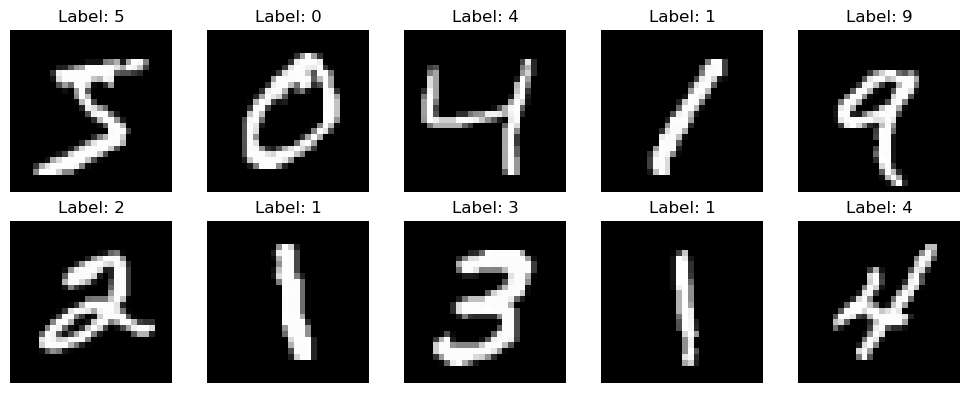

In [3]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Encoding the Labels

In [4]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("Example before:", y_train[0])
print("Example after:", y_train_cat[0])

Example before: 5
Example after: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


## 5. Building the CNN Model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    # First Layer: Extracting features from the image, such as edges and lines.
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    
    # Second Layer: Extracting Deeper and More Complex Features
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    
    # Converting data from a 2D image format to a 1D line so it can be fed into standard layers.
    Flatten(),
    
    # Standard Dense layer for learning
    Dense(128, activation='relu'),
    
    # Dropout: Prevents overfitting by randomly "turning off" a portion of the neurons during training.
    Dropout(0.3),
    
    # Final layer: 10 cells (one for each digit from 0 to 9); Softmax converts the output into probabilities.
    Dense(10, activation='softmax')
])

model.summary()

C:\Users\Fix-Dell\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

## 6. Compiling the Model

In [6]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 7. Training the Model

In [7]:
history = model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 68s 38ms/step - accuracy: 0.9441 - loss: 0.1808 - val_accuracy: 0.9842 - val_loss: 0.0512
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 75s 34ms/step - accuracy: 0.9812 - loss: 0.0637 - val_accuracy: 0.9890 - val_loss: 0.0386
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 58s 34ms/step - accuracy: 0.9864 - loss: 0.0453 - val_accuracy: 0.9890 - val_loss: 0.0400
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 60s 35ms/step - accuracy: 0.9887 - loss: 0.0357 - val_accuracy: 0.9902 - val_loss: 0.0332
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 59s 35ms/step - accuracy: 0.9911 - loss: 0.0291 - val_accuracy: 0.9910 - val_loss: 0.0345


## 8. Visualizing Training Performance

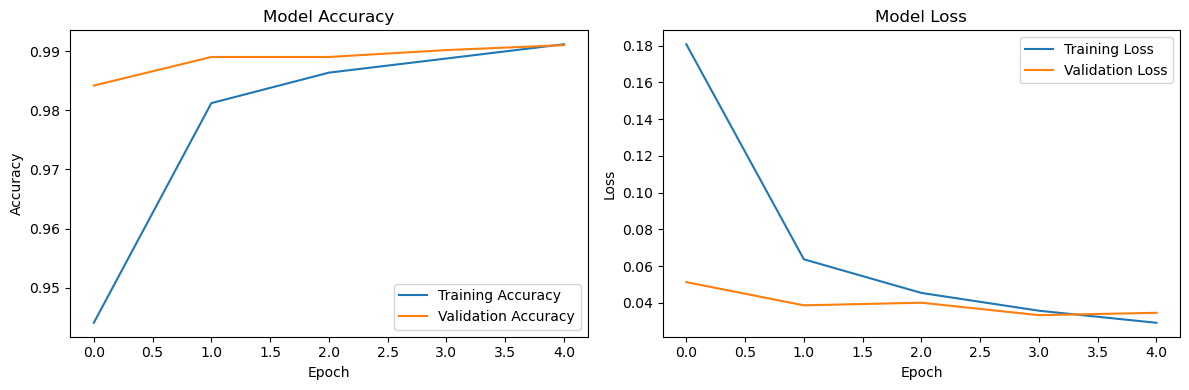

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## 9. Evaluating on Test Data

In [9]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9925 - loss: 0.0250
Test Accuracy: 99.25%
Test Loss: 0.0250


## 10. Testing Predictions Visually

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


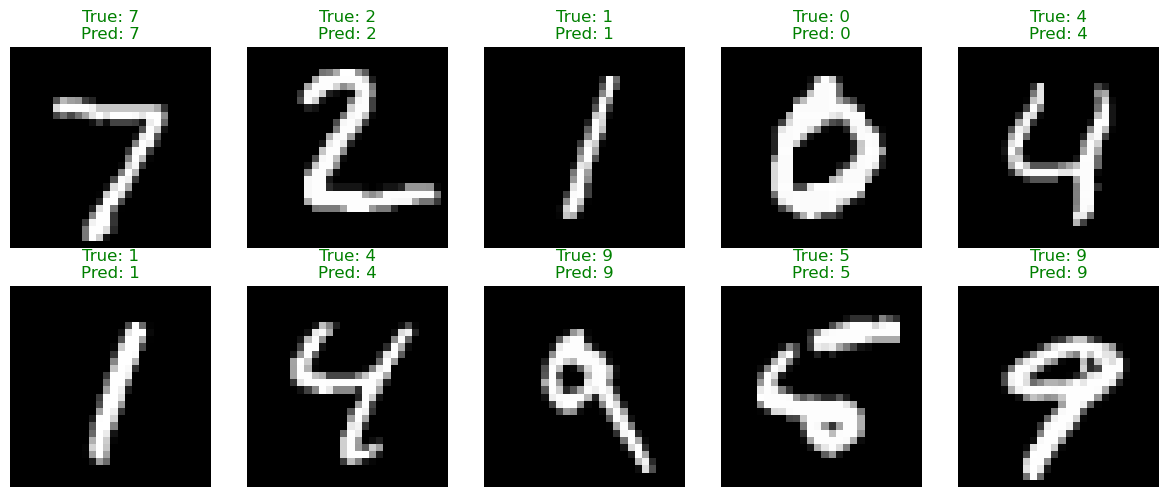

In [12]:
# Predicting the first 10 images from the test data
predictions = model.predict(X_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    color = 'green' if predicted_labels[i] == y_test[i] else 'red'
    plt.title(f"True: {y_test[i]}\nPred: {predicted_labels[i]}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 11. Saving the Model

In [13]:
model.save('mnist_cnn_model.h5')
print("Saved Sucessfully!")

Saved Sucessfully!


## 12. Creating the Streamlit Web App

In [14]:
app_code = '''import streamlit as st
import numpy as np
from tensorflow import keras
from streamlit_drawable_canvas import st_canvas
from PIL import Image
import pandas as pd

st.set_page_config(
    page_title="Digit Recognition AI",
    page_icon="🔢",
    layout="wide",
    initial_sidebar_state="collapsed"
)

st.markdown("""
    <style>
    @import url("https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700;800&display=swap");

    html, body, [class*="css"] {
        font-family: "Poppins", sans-serif;
    }

    .stApp {
        background: radial-gradient(circle at 20% 20%, #1e1b4b 0%, #0f0c29 45%, #050510 100%);
        color: #f1f5f9;
    }

    #MainMenu, footer, header {visibility: hidden;}

    .hero {
        text-align: center;
        padding: 2.5rem 0 1rem 0;
    }
    .hero h1 {
        font-size: 2.6rem;
        font-weight: 800;
        background: linear-gradient(90deg, #a78bfa, #60a5fa, #34d399);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        margin-bottom: 0.3rem;
    }
    .hero p {
        color: #94a3b8;
        font-size: 1rem;
        font-weight: 300;
    }

    .glass-card {
        background: rgba(255, 255, 255, 0.05);
        backdrop-filter: blur(12px);
        border: 1px solid rgba(255, 255, 255, 0.1);
        border-radius: 20px;
        padding: 1.8rem;
        box-shadow: 0 8px 32px rgba(0,0,0,0.3);
    }

    .section-label {
        font-size: 0.85rem;
        text-transform: uppercase;
        letter-spacing: 2px;
        color: #a78bfa;
        font-weight: 600;
        margin-bottom: 1rem;
    }

    div.stButton > button {
        width: 100%;
        background: linear-gradient(90deg, #7c3aed, #3b82f6);
        color: white;
        font-weight: 600;
        font-size: 1rem;
        padding: 0.7rem;
        border-radius: 12px;
        border: none;
        transition: all 0.25s ease;
        box-shadow: 0 4px 15px rgba(124, 58, 237, 0.4);
    }
    div.stButton > button:hover {
        transform: translateY(-2px);
        box-shadow: 0 6px 20px rgba(124, 58, 237, 0.6);
        color: white;
    }

    .result-number {
        font-size: 6rem;
        font-weight: 800;
        text-align: center;
        margin: 0;
        background: linear-gradient(90deg, #34d399, #60a5fa);
        -webkit-background-clip: text;
        -webkit-text-fill-color: transparent;
        line-height: 1;
    }
    .confidence-text {
        text-align: center;
        color: #94a3b8;
        font-size: 0.95rem;
        margin-top: 0.5rem;
    }

    .placeholder-box {
        text-align: center;
        padding: 3rem 1rem;
        color: #64748b;
        font-size: 0.95rem;
    }

    canvas {
        border-radius: 16px !important;
        box-shadow: 0 0 25px rgba(124, 58, 237, 0.35);
    }

    .footer-note {
        text-align: center;
        color: #64748b;
        font-size: 0.8rem;
        margin-top: 3rem;
        padding-bottom: 1rem;
    }
    </style>
""", unsafe_allow_html=True)

model = keras.models.load_model("mnist_cnn_model.h5")

st.markdown("""
    <div class="hero">
        <h1>Digit Recognition AI</h1>
        <p>Draw any digit from 0 to 9 and watch a Convolutional Neural Network read your handwriting in real time.</p>
    </div>
""", unsafe_allow_html=True)

col1, col2 = st.columns([1, 1], gap="large")

with col1:
    st.markdown("<div class='glass-card'>", unsafe_allow_html=True)
    st.markdown("<div class='section-label'>Draw Here</div>", unsafe_allow_html=True)
    canvas_result = st_canvas(
        fill_color="white",
        stroke_width=18,
        stroke_color="#ffffff",
        background_color="#0a0a1a",
        height=300,
        width=300,
        drawing_mode="freedraw",
        key="canvas"
    )
    predict_clicked = st.button("✨ Predict Digit")
    clear_note = st.caption("Use the canvas toolbar (bottom-right of canvas) to clear or undo your drawing.")
    st.markdown("</div>", unsafe_allow_html=True)

with col2:
    st.markdown("<div class='glass-card'>", unsafe_allow_html=True)
    st.markdown("<div class='section-label'>Prediction</div>", unsafe_allow_html=True)

    if predict_clicked and canvas_result.image_data is not None:
        img = canvas_result.image_data.astype("uint8")
        img = Image.fromarray(img).convert("L")
        img = img.resize((28, 28))
        img_array = np.array(img).astype("float32") / 255.0
        img_array = img_array.reshape(1, 28, 28, 1)

        prediction = model.predict(img_array, verbose=0)[0]
        predicted_digit = int(np.argmax(prediction))
        confidence = float(np.max(prediction) * 100)

        st.markdown(f"<p class='result-number'>{predicted_digit}</p>", unsafe_allow_html=True)
        st.markdown(f"<p class='confidence-text'>Model confidence: <b>{confidence:.1f}%</b></p>", unsafe_allow_html=True)

        st.markdown("<br>", unsafe_allow_html=True)
        st.markdown("<div class='section-label'>Probability Breakdown</div>", unsafe_allow_html=True)

        prob_df = pd.DataFrame({
            "Digit": [str(i) for i in range(10)],
            "Probability": prediction * 100
        }).set_index("Digit")

        st.bar_chart(prob_df, color="#7c3aed", height=220)

    elif predict_clicked:
        st.warning("Please draw a digit first.")
    else:
        st.markdown("""
            <div class="placeholder-box">
                Draw a digit on the left, then click<br><b>Predict Digit</b> to see the result here.
            </div>
        """, unsafe_allow_html=True)

    st.markdown("</div>", unsafe_allow_html=True)

st.markdown("""
    <div class="footer-note">
        Built with a Convolutional Neural Network (CNN) trained on the MNIST dataset · 99.1% test accuracy
    </div>
""", unsafe_allow_html=True)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Done! Professional app.py created successfully.")

Done! Professional app.py created successfully.
